In [1]:
import sys
print(sys.executable)


/home/tclark/anaconda3/bin/python


In [2]:
import os
import pandas as pd
from supabase import create_client
from dotenv import load_dotenv

# --- Load environment ---
load_dotenv()
SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_KEY")

# --- Initialize Supabase client ---
supabase = create_client(SUPABASE_URL, SUPABASE_KEY)

# --- Pull data from Supabase ---
response = supabase.table("press_releases_clean").select("*").execute()

# --- Convert to DataFrame ---
articles_df = pd.DataFrame(response.data)

# --- Display preview ---
articles_df.head()


,id,title,url,date_old,scraped_at,content,author,status,updated_at,embedding,date,year,date_standard
0,bc45ed96-feae-446c-9a93-ccd95c198283,Federal Reserve Board - Approval of proposal b...,https://www.federalreserve.gov/newsevents/pres...,2007-10-19,2025-10-30T17:39:51.269085+00:00,FEDERAL RESERVE SYSTEM \nICICI Bank Limited \n...,None,complete,2025-10-30T17:39:51.269077+00:00,None,2007-10-19T00:00:00+00:00,2007.0,2007-10-19T00:00:00+00:00
1,974c6697-f1d5-47b7-8399-bc14ae7f8994,Federal Reserve Board - Federal Reserve Board ...,https://www.federalreserve.gov/newsevents/pres...,None,2025-10-30T18:49:20.877572+00:00,UNITED STATES OF AMERICA \nBEFORE THE \nBOARD ...,None,complete,2025-10-30T18:49:20.877555+00:00,None,None,NaN,None
2,94420629-11b2-497c-9dfb-3eafb9b24e30,Federal Reserve Board - Minutes of the Federal...,https://www.federalreserve.gov/newsevents/pres...,2024-08-21,2025-10-30T17:36:41.818957+00:00,1 \n \nMinutes of the Federal Open Market \nCo...,None,complete,2025-10-30T17:36:41.818948+00:00,None,2024-08-21T00:00:00+00:00,2024.0,2024-08-21T00:00:00+00:00
3,8386ab75-ce0e-444a-bd0a-6851153ad164,Federal Reserve Board - Minutes of the Board's...,https://www.federalreserve.gov/newsevents/pres...,2024-08-27,2025-10-30T17:36:43.716471+00:00,DISCOUNT AND ADVANCE RATES -- Requests by ten ...,None,complete,2025-10-30T17:36:43.716459+00:00,None,2024-08-27T00:00:00+00:00,2024.0,2024-08-27T00:00:00+00:00
4,c8bc9e06-de8f-43d5-93cb-c8105856e816,Federal Reserve Board - Federal Reserve issues...,https://www.federalreserve.gov/newsevents/pres...,2024-09-18,2025-10-30T17:36:45.350035+00:00,For release at 2:00 p.m. E DT Septe...,None,complete,2025-10-30T17:36:45.350021+00:00,None,2024-09-18T00:00:00+00:00,2024.0,2024-09-18T00:00:00+00:00


In [3]:
articles_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             1000 non-null   object 
 1   title          1000 non-null   object 
 2   url            1000 non-null   object 
 3   date_old       652 non-null    object 
 4   scraped_at     1000 non-null   object 
 5   content        1000 non-null   object 
 6   author         0 non-null      object 
 7   status         1000 non-null   object 
 8   updated_at     1000 non-null   object 
 9   embedding      0 non-null      object 
 10  date           652 non-null    object 
 11  year           652 non-null    float64
 12  date_standard  652 non-null    object 
dtypes: float64(1), object(12)
memory usage: 101.7+ KB


In [4]:
# Drop unused columns
articles_df = articles_df.drop(columns=["id", "author"], errors="ignore")

# Confirm structure
articles_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   title          1000 non-null   object 
 1   url            1000 non-null   object 
 2   date_old       652 non-null    object 
 3   scraped_at     1000 non-null   object 
 4   content        1000 non-null   object 
 5   status         1000 non-null   object 
 6   updated_at     1000 non-null   object 
 7   embedding      0 non-null      object 
 8   date           652 non-null    object 
 9   year           652 non-null    float64
 10  date_standard  652 non-null    object 
dtypes: float64(1), object(10)
memory usage: 86.1+ KB


In [5]:
articles_df["word_count"] = articles_df["content"].apply(lambda x: len(str(x).split()))
articles_df[["title", "date", "word_count"]].head(5)


,title,date,word_count
0,Federal Reserve Board - Approval of proposal b...,2007-10-19T00:00:00+00:00,2516
1,Federal Reserve Board - Federal Reserve Board ...,None,1253
2,Federal Reserve Board - Minutes of the Federal...,2024-08-21T00:00:00+00:00,7140
3,Federal Reserve Board - Minutes of the Board's...,2024-08-27T00:00:00+00:00,939
4,Federal Reserve Board - Federal Reserve issues...,2024-09-18T00:00:00+00:00,857


In [6]:
# Ensure 'date' is a real datetime column
articles_df["date"] = pd.to_datetime(articles_df["date"], errors="coerce")

# Drop any rows where date could not be parsed
articles_df = articles_df[articles_df["date"].notnull()]

# Now safely extract year
articles_df["year"] = articles_df["date"].dt.year


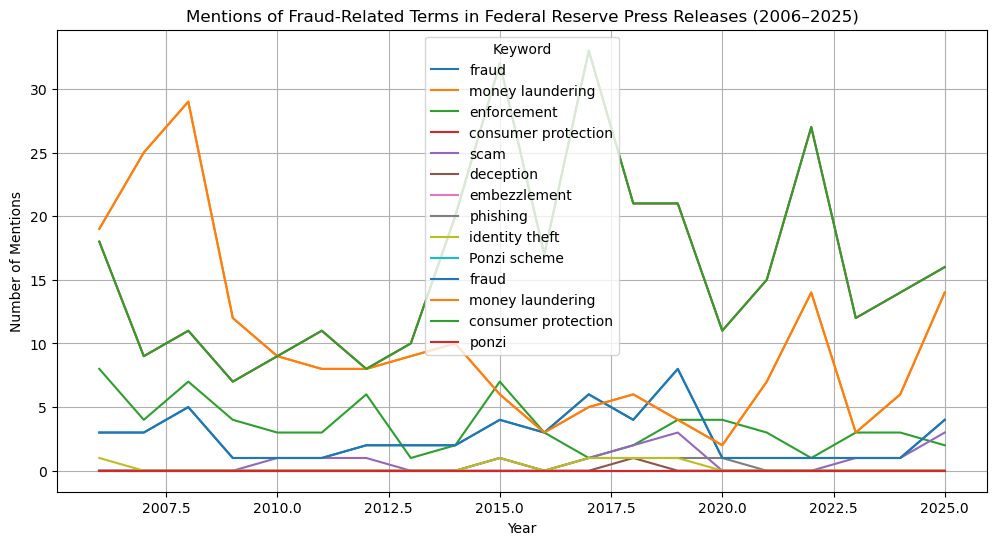

In [7]:
import matplotlib.pyplot as plt

# Make sure dates are datetime and year exists
articles_df["date"] = pd.to_datetime(articles_df["date"], errors="coerce")
articles_df["year"] = articles_df["date"].dt.year

# Combine all text into lowercase for keyword matching
articles_df["content_lower"] = articles_df["content"].fillna("").str.lower()

# Keywords to track
keywords = ["fraud", "money laundering", "enforcement", "consumer protection", "scam", "deception",
            "embezzlement", "phishing", "identity theft", "Ponzi scheme", "fraud", "money laundering",
            "consumer protection", "ponzi"] 

# Count keyword hits per article
for kw in keywords:
    articles_df[kw] = articles_df["content_lower"].str.contains(kw, case=False, na=False)

# Aggregate counts by year
keyword_trends = (
    articles_df.groupby("year")[keywords]
    .sum()
    .reset_index()
)

# Plot the trends
keyword_trends.plot(x="year", figsize=(12,6))
plt.title("Mentions of Fraud-Related Terms in Federal Reserve Press Releases (2006–2025)")
plt.ylabel("Number of Mentions")
plt.xlabel("Year")
plt.legend(title="Keyword")
plt.grid(True)
plt.show()


ModuleNotFoundError: No module named 'src'